In [9]:
!pip install kagglehub -q
import kagglehub
import pandas as pd
import numpy as np
import os

In [10]:
# Download dataset
path = kagglehub.dataset_download("rabieelkharoua/predict-online-gaming-behavior-dataset")
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
data = pd.read_csv(os.path.join(path, csv_file))
data

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...
40029,49029,32,Male,USA,Strategy,20.619662,0,Easy,4,75,85,14,Medium
40030,49030,44,Female,Other,Simulation,13.539280,0,Hard,19,114,71,27,High
40031,49031,15,Female,USA,RPG,0.240057,1,Easy,10,176,29,1,High
40032,49032,34,Male,USA,Sports,14.017818,1,Medium,3,128,70,10,Medium


In [11]:
df = data.loc[:, ['SessionsPerWeek', 'AchievementsUnlocked', 'PlayerLevel', 'AvgSessionDurationMinutes','EngagementLevel']] 
df.to_csv("datause.csv", index=False)
df 

,SessionsPerWeek,AchievementsUnlocked,PlayerLevel,AvgSessionDurationMinutes,EngagementLevel
0,6,25,79,108,Medium
1,5,10,11,144,Medium
2,16,41,35,142,High
3,9,47,57,85,Medium
4,2,37,95,131,Medium
...,...,...,...,...,...
40029,4,14,85,75,Medium
40030,19,27,71,114,High
40031,10,1,29,176,High
40032,3,10,70,128,Medium


# Model training and evaluation (80% train, 20%test)

In [13]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
# =========================
# Feature & Target
# =========================
X = df[['SessionsPerWeek',
           'AchievementsUnlocked', 'PlayerLevel',
           'AvgSessionDurationMinutes']]

le = LabelEncoder()
y = le.fit_transform(df["EngagementLevel"])

# =========================
# Train-test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# Pipeline (without class_weight)
# =========================
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        solver="lbfgs",
        max_iter=1000,
    ))
])

param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="f1_macro",
)

# =========================
# Train model
# =========================
grid.fit(X_train, y_train)

# =========================
# ROC
# =========================

best_model = grid.best_estimator_
y_proba = best_model.predict_proba(X_test)

roc_auc = roc_auc_score(
    y_test,
    y_proba,
    multi_class="ovr",
    average="macro"
)

print("\n===== ROC-AUC (No class_weight) =====")
print(f"ROC-AUC: {roc_auc:.4f}")

cv_scores = cross_val_score(
    grid.best_estimator_,
    X_train,
    y_train,
    cv=5,
    scoring="f1_macro"
)

print("\n===== CV (No class_weight) =====")
print(f"CV F1 Macro Mean: {cv_scores.mean():.4f}")
print(f"CV F1 Macro Std : {cv_scores.std():.4f}")

print("\n===== Best Parameters (No class_weight) =====")
print(grid.best_params_)
print("Best CV Score:", grid.best_score_)

# =========================
# Test evaluation
# =========================
y_pred = grid.predict(X_test)

print("\n===== Test Report (No class_weight) =====")
print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

# =========================
# Pipeline (with class_weight)
# =========================
pipe_balanced = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        solver="lbfgs",
        class_weight="balanced",
        max_iter=1000,
    ))
])

grid_balanced = GridSearchCV(
    pipe_balanced,
    param_grid,
    cv=5,
    scoring="f1_macro",
)

# =========================
# Train balanced model
# =========================
grid_balanced.fit(X_train, y_train)

# =========================
# ROC
# =========================
best_model_bal = grid_balanced.best_estimator_
y_proba_bal= best_model_bal.predict_proba(X_test)

roc_auc_bal = roc_auc_score(
    y_test,
    y_proba_bal,
    multi_class="ovr",
    average="macro"
)

print("\n===== ROC-AUC (Balanced) =====")
print(f"ROC-AUC: {roc_auc_bal:.4f}")

cv_scores_bal = cross_val_score(
    grid_balanced.best_estimator_,
    X_train,
    y_train,
    cv=5,
    scoring="f1_macro"
)

print("\n===== CV (Balanced) =====")
print(f"CV F1 Macro Mean: {cv_scores_bal.mean():.4f}")
print(f"CV F1 Macro Std : {cv_scores_bal.std():.4f}")

print("\n===== Best Parameters (Balanced) =====")
print(grid_balanced.best_params_)
print("Best CV Score:", grid_balanced.best_score_)

# =========================
# 8. Test evaluation (balanced)
# =========================
y_pred_bal = grid_balanced.predict(X_test)

print("\n===== Test Report (Balanced) =====")
print(classification_report(
    y_test,
    y_pred_bal,
    target_names=le.classes_
))


===== ROC-AUC (No class_weight) =====
ROC-AUC: 0.9130

===== CV (No class_weight) =====
CV F1 Macro Mean: 0.8179
CV F1 Macro Std : 0.0072

===== Best Parameters (No class_weight) =====
{'model__C': 0.1}
Best CV Score: 0.8179307341744074

===== Test Report (No class_weight) =====
              precision    recall  f1-score   support

        High       0.89      0.83      0.86      2067
         Low       0.79      0.69      0.74      2065
      Medium       0.80      0.88      0.84      3875

    accuracy                           0.82      8007
   macro avg       0.83      0.80      0.81      8007
weighted avg       0.82      0.82      0.82      8007


===== ROC-AUC (Balanced) =====
ROC-AUC: 0.9129

===== CV (Balanced) =====
CV F1 Macro Mean: 0.7901
CV F1 Macro Std : 0.0065

===== Best Parameters (Balanced) =====
{'model__C': 10}
Best CV Score: 0.7900983058266471

===== Test Report (Balanced) =====
              precision    recall  f1-score   support

        High       0.78      0.

## Coefficients (Balanced Logistic Regression)

In [14]:
# =========================
# Coefficients (Balanced Logistic Regression)
# =========================

best_balanced_model = grid_balanced.best_estimator_
log_model = best_balanced_model.named_steps["model"]

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
})

coef_df = coef_df.sort_values(by="Coefficient", ascending=False)

print("\n===== Balanced Model Coefficients =====")
print(coef_df)


===== Balanced Model Coefficients =====
                     Feature  Coefficient
0            SessionsPerWeek     1.873385
3  AvgSessionDurationMinutes     1.622437
1       AchievementsUnlocked     0.144934
2                PlayerLevel     0.135501


# Different C value vs their corresponding F1-score, Accuracy, and Log-loss for Logistic Regression

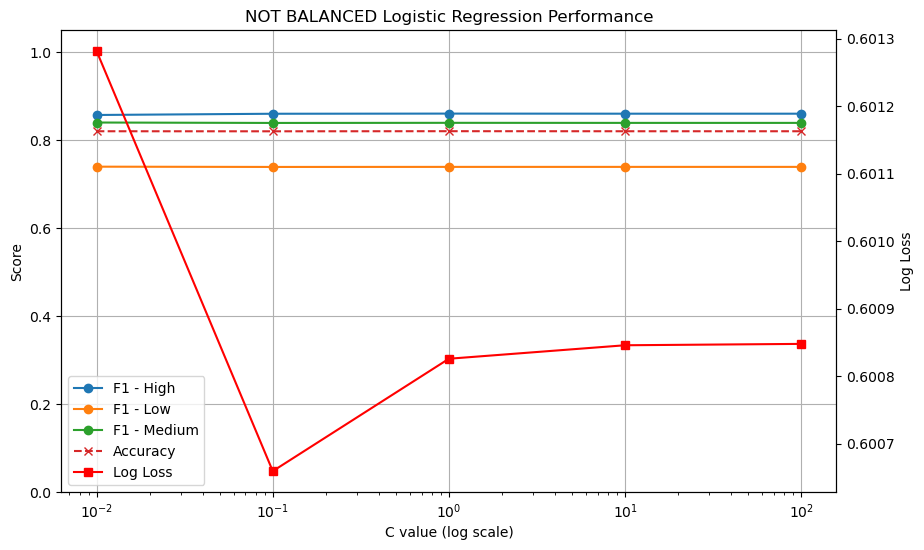

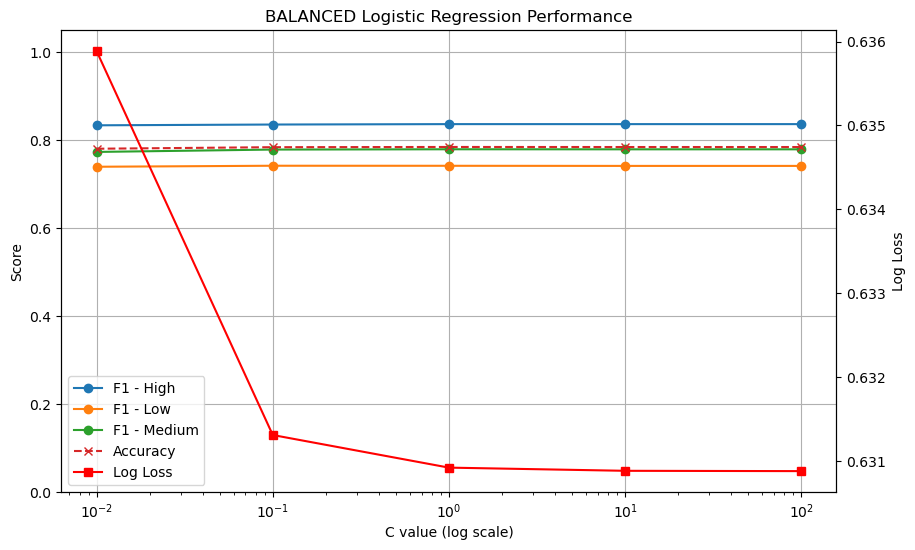

In [15]:
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, log_loss

class_names = le.classes_

# =========================
# Containers
# =========================
f1_nb = {name: [] for name in class_names}
acc_nb, ll_nb = [], []

f1_b = {name: [] for name in class_names}
acc_b, ll_b = [], []

# =========================
# Training loop
# =========================
C_values = [0.01, 0.1, 1, 10, 100]
for C in C_values:

    # =========================
    # Not Balanced
    # =========================
    model_nb = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(C=C, max_iter=1000))
    ])

    model_nb.fit(X_train, y_train)
    pred_nb = model_nb.predict(X_test)
    proba_nb = model_nb.predict_proba(X_test)

    report_nb = classification_report(y_test, pred_nb, output_dict=True)

    for i, name in enumerate(class_names):
        f1_nb[name].append(report_nb[str(i)]["f1-score"])

    acc_nb.append(accuracy_score(y_test, pred_nb))
    ll_nb.append(log_loss(y_test, proba_nb))


    # =========================
    # Balanced
    # =========================
    model_b = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=C,
            class_weight="balanced",
            max_iter=1000
        ))
    ])

    model_b.fit(X_train, y_train)
    pred_b = model_b.predict(X_test)
    proba_b = model_b.predict_proba(X_test)

    report_b = classification_report(y_test, pred_b, output_dict=True)

    for i, name in enumerate(class_names):
        f1_b[name].append(report_b[str(i)]["f1-score"])

    acc_b.append(accuracy_score(y_test, pred_b))
    ll_b.append(log_loss(y_test, proba_b))

# =========================================================
# FIGURE 1: NOT BALANCED
# =========================================================
fig1, ax1 = plt.subplots(figsize=(10,6))

for name in class_names:
    ax1.plot(C_values, f1_nb[name], marker='o', label=f'F1 - {name}')

ax1.plot(C_values, acc_nb, marker='x', linestyle='--', label='Accuracy')

ax1.set_xscale('log')
ax1.set_xlabel("C value (log scale)")
ax1.set_ylabel("Score")
ax1.set_ylim(0, 1.05)
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(C_values, ll_nb, marker='s', color='red', label='Log Loss')
ax2.set_ylabel("Log Loss")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.title("NOT BALANCED Logistic Regression Performance")
plt.show()


# =========================================================
# FIGURE 2: BALANCED
# =========================================================
fig2, ax1 = plt.subplots(figsize=(10,6))

for name in class_names:
    ax1.plot(C_values, f1_b[name], marker='o', label=f'F1 - {name}')

ax1.plot(C_values, acc_b, marker='x', linestyle='--', label='Accuracy')

ax1.set_xscale('log')
ax1.set_xlabel("C value (log scale)")
ax1.set_ylabel("Score")
ax1.set_ylim(0, 1.05)
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(C_values, ll_b, marker='s', color='red', label='Log Loss')
ax2.set_ylabel("Log Loss")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.title("BALANCED Logistic Regression Performance")
plt.show()

# Decision Boundary of Logistic Regression for User Engagement Levels

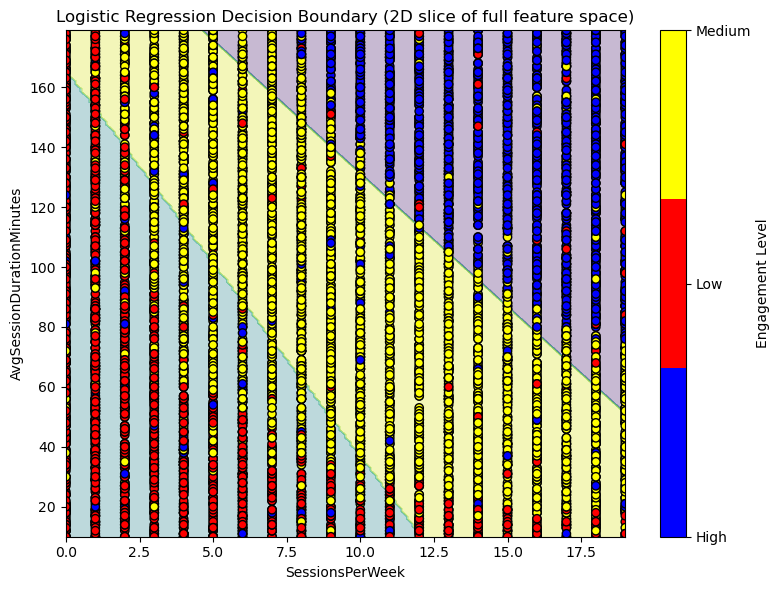

Classes: ['High' 'Low' 'Medium']


In [17]:
from matplotlib.colors import ListedColormap
# =========================
# FIXED VALUES
# =========================
fixed = X_train.mean()

# =========================
# 2. GRID (2D space)
# =========================
x_min, x_max = X["SessionsPerWeek"].min(), X["SessionsPerWeek"].max()
y_min, y_max = X["AvgSessionDurationMinutes"].min(), X["AvgSessionDurationMinutes"].max()

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# =========================
# FULL FEATURE GRID 
# =========================
grid = pd.DataFrame(
    np.tile(fixed.values, (xx.size, 1)),
    columns=X_train.columns
)

# overwrite 2 features
grid["SessionsPerWeek"] = xx.ravel()
grid["AvgSessionDurationMinutes"] = yy.ravel()

# =========================
# PREDICT (FIX WARNING)
# =========================
Z = best_model_bal.predict(grid)   # 
Z = Z.reshape(xx.shape)

# =========================
# PLOT
# =========================
plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")

cmap = ListedColormap(["blue", "red", "yellow"])

plt.scatter(
    X_test["SessionsPerWeek"],
    X_test["AvgSessionDurationMinutes"],
    c=y_test,
    cmap=cmap,
    edgecolor="k"
)

plt.xlabel("SessionsPerWeek")
plt.ylabel("AvgSessionDurationMinutes")
plt.title("Logistic Regression Decision Boundary (2D slice of full feature space)")

cbar = plt.colorbar(ticks=[0,1,2])
cbar.set_label("Engagement Level")
cbar.set_ticklabels(le.classes_)

plt.tight_layout()
plt.show()

print("Classes:", le.classes_)

# Logistic Regression Coefficients for High / Medium / Low Engagement

Engagement Level:
0: High
1: Low
2: Medium
   SessionsPerWeek  AchievementsUnlocked  PlayerLevel  \
0         2.160075              0.170933     0.158663   
1        -2.038704             -0.239362    -0.221659   
2        -0.121371              0.068429     0.062997   

   AvgSessionDurationMinutes  
0                   1.849965  
1                  -1.553201  
2                  -0.296764  


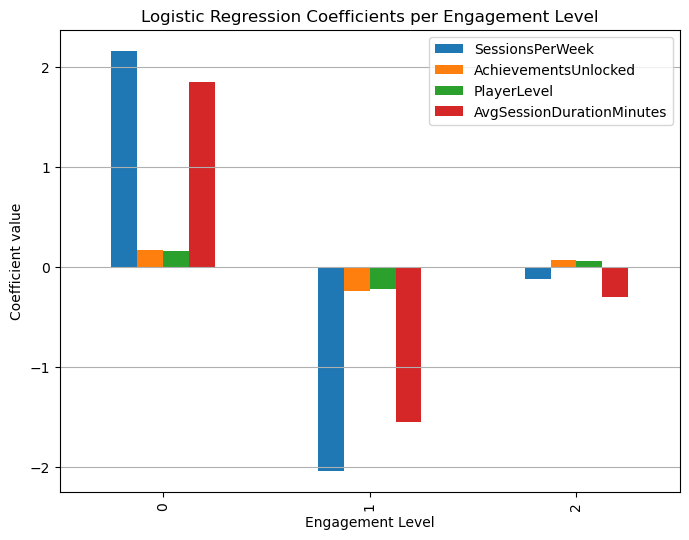

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(solver="lbfgs", max_iter=1000))
])

pipe.fit(X_train, y_train)
model = pipe.named_steps['lr']

# Get internal category code
classes = model.classes_

print("Engagement Level:")
for i, class_name in enumerate(le.classes_):
    print(f"{i}: {class_name}")

coef_df = pd.DataFrame(model.coef_, columns=X_train.columns, index=classes)
print(coef_df)

coef_df.plot(kind='bar', figsize=(8,6))
plt.title("Logistic Regression Coefficients per Engagement Level")
plt.ylabel("Coefficient value")
plt.xlabel("Engagement Level")
plt.grid(axis='y')
plt.show()

# Confusion Matrix

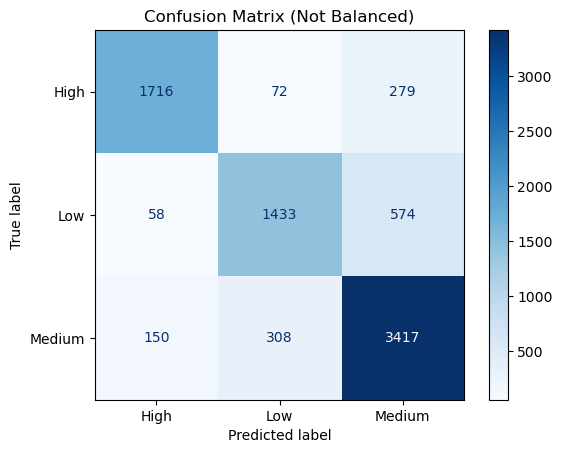

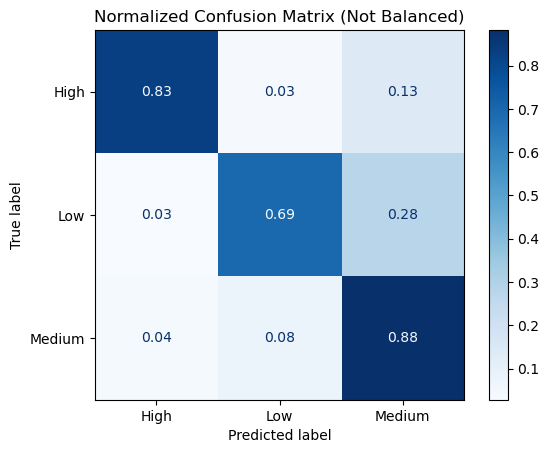

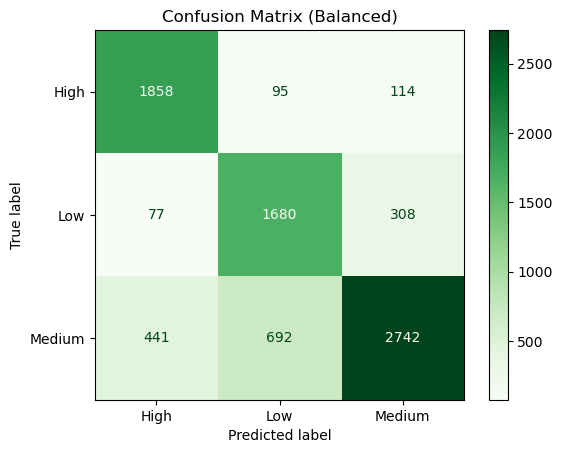

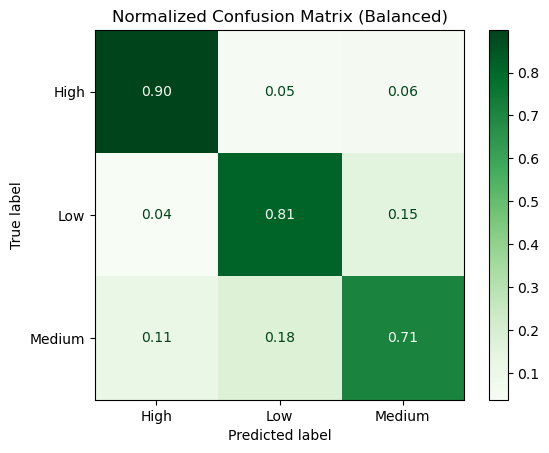

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#==========balanced==========
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Not Balanced)")
plt.show()

# Normalized
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')

disp_norm = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=le.classes_
)

disp_norm.plot(cmap="Blues", values_format=".2f")
plt.title("Normalized Confusion Matrix (Not Balanced)")
plt.show()

#==========balanced==========
cm_bal = confusion_matrix(y_test, y_pred_bal)

disp_bal = ConfusionMatrixDisplay(
    confusion_matrix=cm_bal,
    display_labels=le.classes_
)

disp_bal.plot(cmap="Greens")
plt.title("Confusion Matrix (Balanced)")
plt.show()

# Normalized
cm_bal_norm = confusion_matrix(y_test, y_pred_bal, normalize='true')

disp_bal_norm = ConfusionMatrixDisplay(
    confusion_matrix=cm_bal_norm,
    display_labels=le.classes_
)

disp_bal_norm.plot(cmap="Greens", values_format=".2f")
plt.title("Normalized Confusion Matrix (Balanced)")
plt.show()

# Train and Test Loss Convergence of SGD Logistic Regression (80/20 Split)

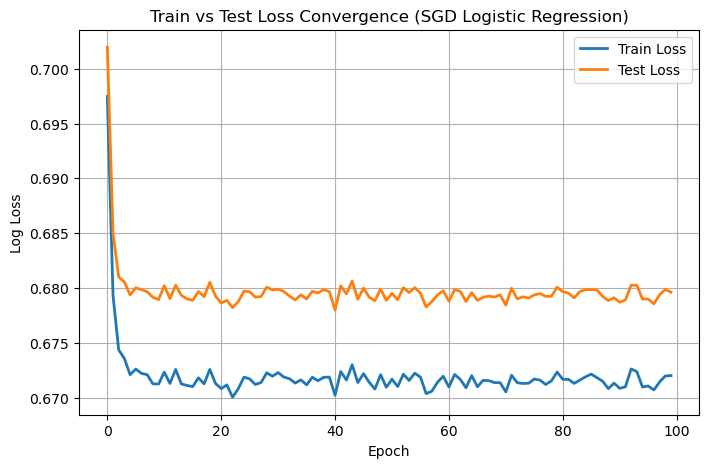

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler

# =========================
# standardize
# =========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# SGD Logistic Regression
# =========================
clf = SGDClassifier(
    loss="log_loss",
    learning_rate="constant",
    eta0=0.001,
    random_state=42
)

classes = np.unique(y_train)

train_losses = []
test_losses = []

# =========================
# Training loop
# =========================
for epoch in range(100):

    # shuffle
    idx = np.random.permutation(len(X_train_scaled))
    X_batch = X_train_scaled[idx]
    y_batch = y_train[idx]

    # partial fit
    clf.partial_fit(X_batch, y_batch, classes=classes)

    # =========================
    # Train loss
    # =========================
    y_prob_train = clf.predict_proba(X_train_scaled)
    y_prob_train = np.clip(y_prob_train, 1e-10, 1 - 1e-10)
    train_loss = log_loss(y_train, y_prob_train)
    train_losses.append(train_loss)

    # =========================
    # Test loss
    # =========================
    y_prob_test = clf.predict_proba(X_test_scaled)
    y_prob_test = np.clip(y_prob_test, 1e-10, 1 - 1e-10)
    test_loss = log_loss(y_test, y_prob_test)
    test_losses.append(test_loss)

# =========================
# Plot
# =========================
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss", linewidth=2)
plt.plot(test_losses, label="Test Loss", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Train vs Test Loss Convergence (SGD Logistic Regression)")
plt.legend()
plt.grid(True)

plt.show()

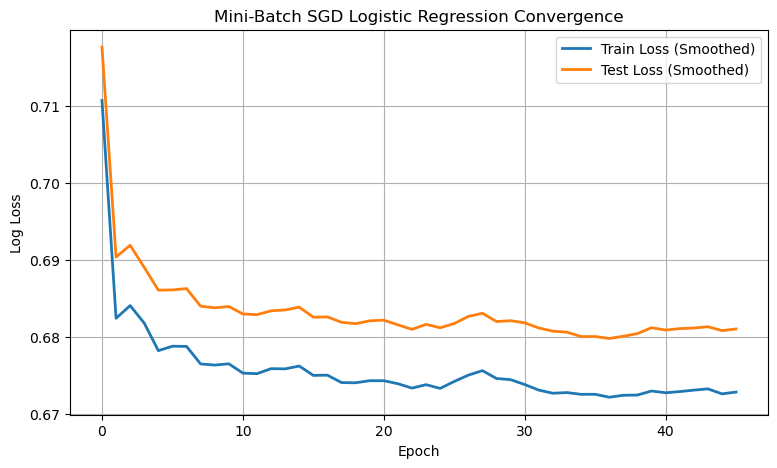

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler

# =========================
# Standardization
# =========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# SGD Logistic Regression
# =========================
clf = SGDClassifier(
    loss="log_loss",
    learning_rate="optimal",  
    random_state=42
)

classes = np.unique(y_train)

# =========================
# params
# =========================
epochs = 50
batch_size = 32

train_losses = []
test_losses = []

# =========================
# Training loop (Mini-batch SGD)
# =========================
for epoch in range(epochs):

    # shuffle
    idx = np.random.permutation(len(X_train_scaled))
    X_train_shuffled = X_train_scaled[idx]
    y_train_shuffled = y_train[idx]

    # mini-batch training
    for i in range(0, len(X_train_scaled), batch_size):
        X_batch = X_train_shuffled[i:i+batch_size]
        y_batch = y_train_shuffled[i:i+batch_size]

        clf.partial_fit(X_batch, y_batch, classes=classes)

    # =========================
    # Train loss
    # =========================
    y_prob_train = clf.predict_proba(X_train_scaled)
    y_prob_train = np.clip(y_prob_train, 1e-10, 1 - 1e-10)
    train_loss = log_loss(y_train, y_prob_train)
    train_losses.append(train_loss)

    # =========================
    # Test loss
    # =========================
    y_prob_test = clf.predict_proba(X_test_scaled)
    y_prob_test = np.clip(y_prob_test, 1e-10, 1 - 1e-10)
    test_loss = log_loss(y_test, y_prob_test)
    test_losses.append(test_loss)

# =========================
# Smooth curve
# =========================
def smooth_curve(data, window=5):
    return np.convolve(data, np.ones(window)/window, mode='valid')

train_smooth = smooth_curve(train_losses)
test_smooth = smooth_curve(test_losses)

# =========================
# Plot (publication style)
# =========================
plt.figure(figsize=(9,5))

plt.plot(train_smooth, label="Train Loss (Smoothed)", linewidth=2)
plt.plot(test_smooth, label="Test Loss (Smoothed)", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Mini-Batch SGD Logistic Regression Convergence")
plt.legend()
plt.grid(True)

plt.show()

# FULL DATA trining (GridsearchCV)

In [22]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# =========================
# Feature & Target
# =========================
X = df[['SessionsPerWeek',
        'AchievementsUnlocked',
        'PlayerLevel',
        'AvgSessionDurationMinutes']]

le = LabelEncoder()
y = le.fit_transform(df["EngagementLevel"])

# =========================
# Pipeline (No class_weight)
# =========================
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        solver="lbfgs",
        max_iter=1000
    ))
])

param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="f1_macro",
)

# =========================
# Train on FULL DATA
# =========================
grid.fit(X, y)

# =========================
# Cross-validation F1
# =========================
cv_scores = cross_val_score(
    grid.best_estimator_,
    X,
    y,
    cv=5,
    scoring="f1_macro"
)

# =========================
# Cross-validation ROC AUC
# =========================
cv_auc = cross_val_score(
    grid.best_estimator_,
    X,
    y,
    cv=5,
    scoring="roc_auc_ovr"
)

print("\n===== CROSS VALIDATION (FULL DATA MODEL) =====")
print(f"CV F1 Macro Mean : {cv_scores.mean():.4f}")
print(f"CV F1 Macro Std  : {cv_scores.std():.4f}")
print(f"CV ROC AUC Mean  : {cv_auc.mean():.4f}")
print(f"CV ROC AUC Std   : {cv_auc.std():.4f}")

print("\n===== Best Parameters (Full Data, No class_weight) =====")
print(grid.best_params_)
print("Best CV F1 Score:", grid.best_score_)

# =========================
# In-sample evaluation
# =========================
y_pred = grid.predict(X)
y_proba = grid.predict_proba(X)

print("\n--- Full Data Evaluation (NOT generalization) ---")
print(f"Accuracy: {accuracy_score(y, y_pred):.4f}")

# ROC AUC (multiclass OVR)
auc_in_sample = roc_auc_score(y, y_proba, multi_class="ovr")

print(f"ROC AUC (In-sample): {auc_in_sample:.4f}")

print(classification_report(
    y,
    y_pred,
    target_names=le.classes_
))

# =========================
# BALANCED MODEL
# =========================
pipe_balanced = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        solver="lbfgs",
        class_weight="balanced",
        max_iter=1000
    ))
])

grid_balanced = GridSearchCV(
    pipe_balanced,
    param_grid,
    cv=5,
    scoring="f1_macro",
)

# =========================
# Train balanced model
# =========================
grid_balanced.fit(X, y)

# =========================
# CV F1
# =========================
cv_scores_bal = cross_val_score(
    grid_balanced.best_estimator_,
    X,
    y,
    cv=5,
    scoring="f1_macro"
)

# =========================
# CV ROC AUC
# =========================
cv_auc_bal = cross_val_score(
    grid_balanced.best_estimator_,
    X,
    y,
    cv=5,
    scoring="roc_auc_ovr"
)

print("\n===== CROSS VALIDATION (BALANCED MODEL) =====")
print(f"CV F1 Macro Mean : {cv_scores_bal.mean():.4f}")
print(f"CV F1 Macro Std  : {cv_scores_bal.std():.4f}")
print(f"CV ROC AUC Mean  : {cv_auc_bal.mean():.4f}")
print(f"CV ROC AUC Std   : {cv_auc_bal.std():.4f}")

print("\n===== Best Parameters (Balanced, Full Data) =====")
print(grid_balanced.best_params_)
print("Best CV F1 Score:", grid_balanced.best_score_)


===== CROSS VALIDATION (FULL DATA MODEL) =====
CV F1 Macro Mean : 0.8165
CV F1 Macro Std  : 0.0043
CV ROC AUC Mean  : 0.9152
CV ROC AUC Std   : 0.0041

===== Best Parameters (Full Data, No class_weight) =====
{'model__C': 10}
Best CV F1 Score: 0.8164954722084259

--- Full Data Evaluation (NOT generalization) ---
Accuracy: 0.8230
ROC AUC (In-sample): 0.9153
              precision    recall  f1-score   support

        High       0.90      0.83      0.86     10336
         Low       0.80      0.70      0.75     10324
      Medium       0.80      0.88      0.84     19374

    accuracy                           0.82     40034
   macro avg       0.83      0.80      0.82     40034
weighted avg       0.82      0.82      0.82     40034


===== CROSS VALIDATION (BALANCED MODEL) =====
CV F1 Macro Mean : 0.7887
CV F1 Macro Std  : 0.0047
CV ROC AUC Mean  : 0.9151
CV ROC AUC Std   : 0.0040

===== Best Parameters (Balanced, Full Data) =====
{'model__C': 10}
Best CV F1 Score: 0.7887086035219946


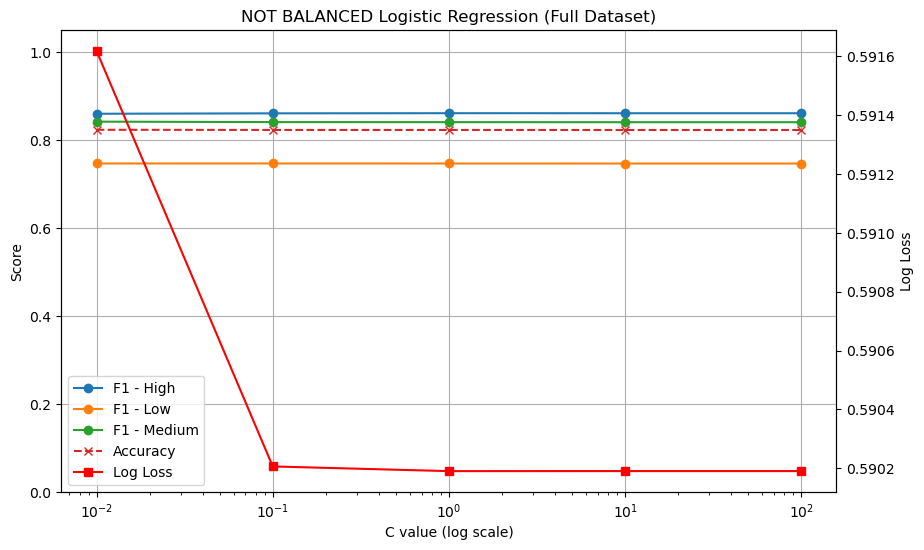

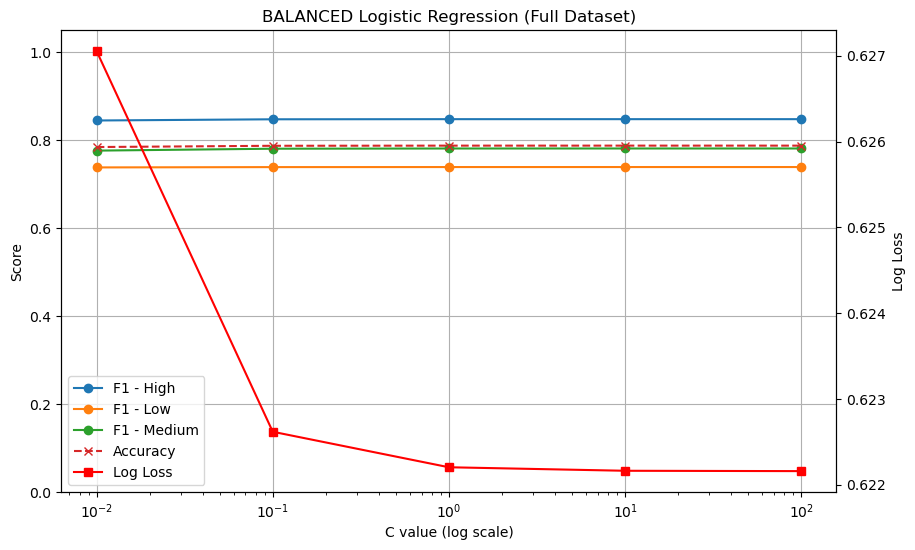

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, log_loss

# =========================
# Full dataset
# =========================
X_full = X
y_full = y

# =========================
# Containers
# =========================
class_names = le.classes_
f1_nb = {name: [] for name in class_names}
acc_nb, ll_nb = [], []

f1_b = {name: [] for name in class_names}
acc_b, ll_b = [], []

# =========================
# Training loop over C
# =========================
C_values = [0.01, 0.1, 1, 10, 100]
for C in C_values:
    # =========================
    # NOT BALANCED
    # =========================
    model_nb = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(C=C, max_iter=1000))
    ])

    model_nb.fit(X_full, y_full)
    pred_nb = model_nb.predict(X_full)
    proba_nb = model_nb.predict_proba(X_full)

    report_nb = classification_report(y_full, pred_nb, output_dict=True)

    for i, name in enumerate(class_names):
        f1_nb[name].append(report_nb[str(i)]["f1-score"])

    acc_nb.append(accuracy_score(y_full, pred_nb))
    ll_nb.append(log_loss(y_full, proba_nb))

    # =========================
    # BALANCED
    # =========================
    model_b = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=C,
            class_weight="balanced",
            max_iter=1000
        ))
    ])

    model_b.fit(X_full, y_full)
    pred_b = model_b.predict(X_full)
    proba_b = model_b.predict_proba(X_full)

    report_b = classification_report(y_full, pred_b, output_dict=True)

    for i, name in enumerate(class_names):
        f1_b[name].append(report_b[str(i)]["f1-score"])

    acc_b.append(accuracy_score(y_full, pred_b))
    ll_b.append(log_loss(y_full, proba_b))

# =========================================================
# NOT BALANCED (FULL DATA)
# =========================================================
fig1, ax1 = plt.subplots(figsize=(10,6))

for name in class_names:
    ax1.plot(C_values, f1_nb[name], marker='o', label=f'F1 - {name}')

ax1.plot(C_values, acc_nb, marker='x', linestyle='--', label='Accuracy')

ax1.set_xscale('log')
ax1.set_xlabel("C value (log scale)")
ax1.set_ylabel("Score")
ax1.set_ylim(0, 1.05)
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(C_values, ll_nb, marker='s', color='red', label='Log Loss')
ax2.set_ylabel("Log Loss")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.title("NOT BALANCED Logistic Regression (Full Dataset)")
plt.show()


# =========================================================
# BALANCED (FULL DATA)
# =========================================================
fig2, ax1 = plt.subplots(figsize=(10,6))

for name in class_names:
    ax1.plot(C_values, f1_b[name], marker='o', label=f'F1 - {name}')

ax1.plot(C_values, acc_b, marker='x', linestyle='--', label='Accuracy')

ax1.set_xscale('log')
ax1.set_xlabel("C value (log scale)")
ax1.set_ylabel("Score")
ax1.set_ylim(0, 1.05)
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(C_values, ll_b, marker='s', color='red', label='Log Loss')
ax2.set_ylabel("Log Loss")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.title("BALANCED Logistic Regression (Full Dataset)")
plt.show()

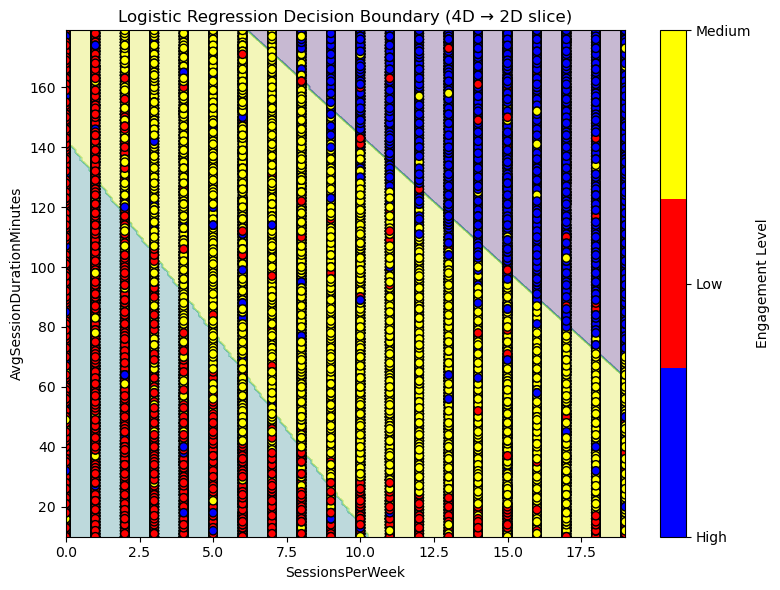

Pipeline(steps=[('scaler', StandardScaler()),
                ('lr', LogisticRegression(max_iter=1000))])
Classes: ['High' 'Low' 'Medium']


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from matplotlib.colors import ListedColormap

# =========================
# Features
# =========================
features = [
    'SessionsPerWeek',
    'AchievementsUnlocked',
    'PlayerLevel',
    'AvgSessionDurationMinutes'
]

X = df[features].copy()
y_raw = df["EngagementLevel"].copy()

# =========================
# Encode target
# =========================
le = LabelEncoder()
y = le.fit_transform(y_raw)

# =========================
# Clean data (IMPORTANT FIX)
# =========================
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(X.mean())  

# =========================
# Model (stable version)
# =========================
model = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        max_iter=1000,
        solver="lbfgs"
    ))
])

model.fit(X, y)

# =========================
# fixed values
# =========================
fixed = X.mean()

# =========================
# grid (2D slice)
# =========================
x_min, x_max = X["SessionsPerWeek"].min(), X["SessionsPerWeek"].max()
y_min, y_max = X["AvgSessionDurationMinutes"].min(), X["AvgSessionDurationMinutes"].max()

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# =========================
# full 4D grid
# =========================
grid_df = pd.DataFrame({
    "SessionsPerWeek": xx.ravel(),
    "AchievementsUnlocked": fixed["AchievementsUnlocked"],
    "PlayerLevel": fixed["PlayerLevel"],
    "AvgSessionDurationMinutes": yy.ravel()
})

grid_df = grid_df[features]

# =========================
# predict
# =========================
Z = model.predict(grid_df)
Z = Z.reshape(xx.shape)

# =========================
# plot
# =========================
plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")

cmap = ListedColormap(["blue", "red", "yellow"])

plt.scatter(
    X["SessionsPerWeek"],
    X["AvgSessionDurationMinutes"],
    c=y,
    cmap=cmap,
    edgecolor="k"
)

plt.xlabel("SessionsPerWeek")
plt.ylabel("AvgSessionDurationMinutes")
plt.title("Logistic Regression Decision Boundary (4D → 2D slice)")

cbar = plt.colorbar(ticks=[0, 1, 2])
cbar.set_label("Engagement Level")
cbar.set_ticklabels(le.classes_)

plt.tight_layout()
plt.show()

print(model)
print("Classes:", le.classes_)

Engagement Level: ['High' 'Low' 'Medium']
        SessionsPerWeek  AchievementsUnlocked  PlayerLevel  \
High           2.136463              0.166200     0.164979   
Low           -2.030813             -0.238394    -0.228475   
Medium        -0.105650              0.072194     0.063496   

        AvgSessionDurationMinutes  
High                     1.830846  
Low                     -1.548895  
Medium                  -0.281951  


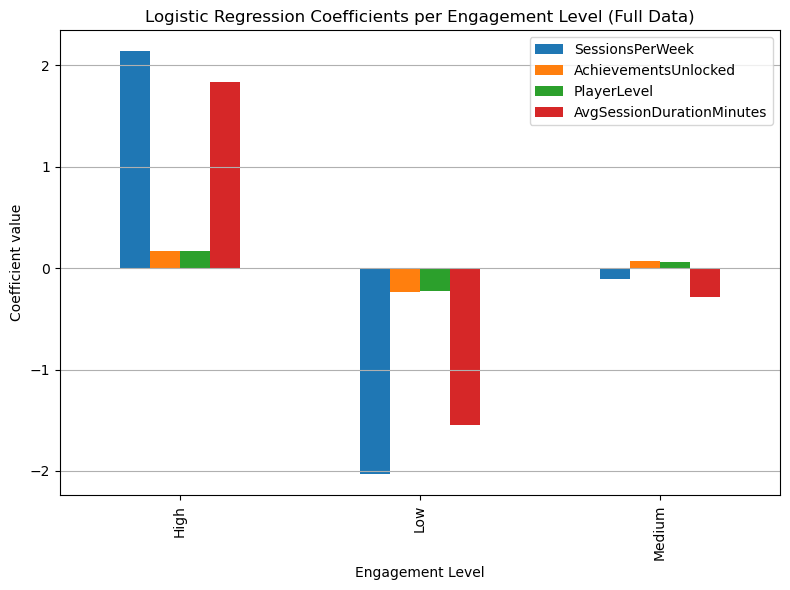

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# ===== encode labels =====
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)   # Use original label

# ===== model =====
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(solver="lbfgs", max_iter=1000))
])

# FULL DATA
pipe.fit(X, y_encoded)

model = pipe.named_steps['lr']

# ===== Replace 0/1/2 with the category name =====
class_names = le.classes_

print("Engagement Level:", class_names)

# ===== coef dataframe =====
coef_df = pd.DataFrame(
    model.coef_,
    columns=X.columns,
    index=class_names   # name
)

print(coef_df)

# ===== plot =====
coef_df.plot(kind='bar', figsize=(8,6))

plt.title("Logistic Regression Coefficients per Engagement Level (Full Data)")
plt.ylabel("Coefficient value")
plt.xlabel("Engagement Level")
plt.grid(axis='y')

plt.tight_layout()
plt.show()

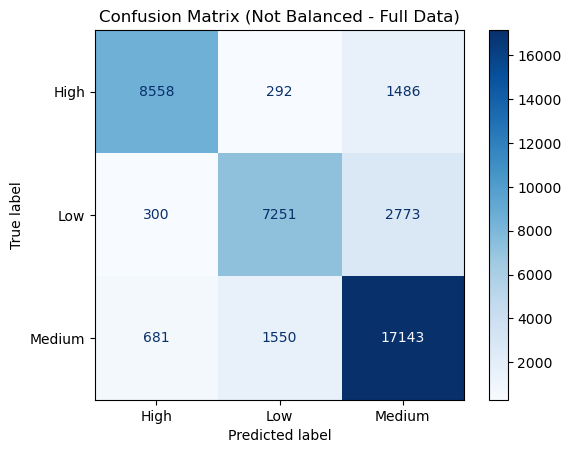

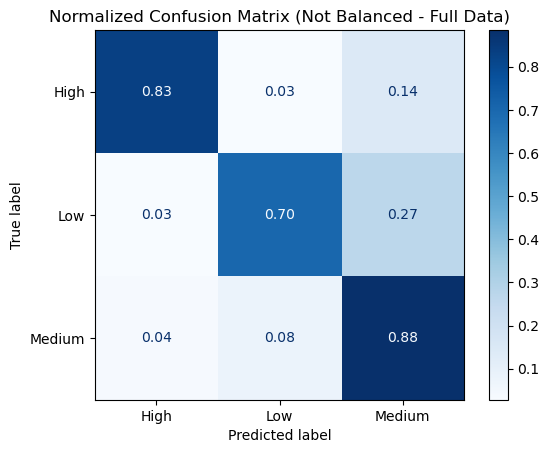

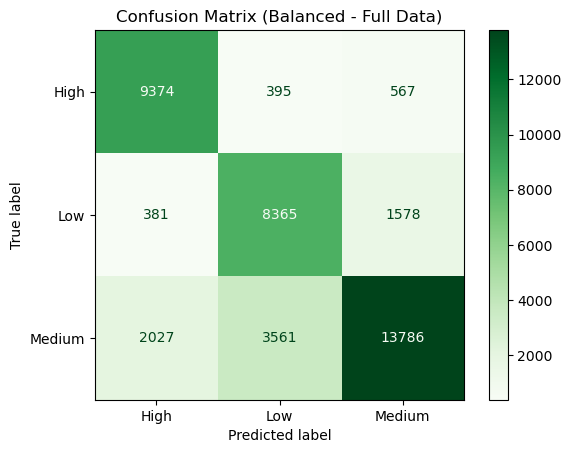

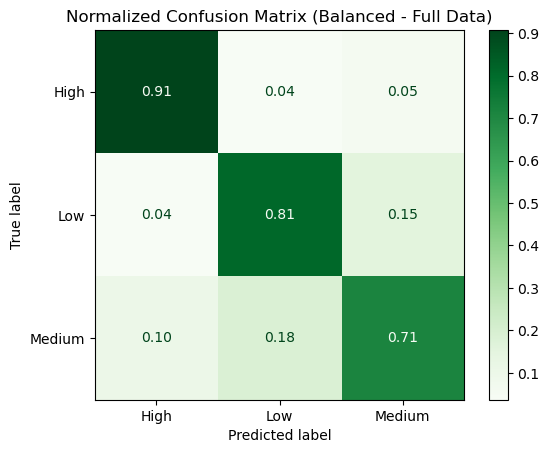

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# =========================
# Full dataset
# =========================
X_full = X
y_full = y

# =========================================================
# NOT BALANCED MODEL
# =========================================================
model_nb = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

model_nb.fit(X_full, y_full)
y_pred_nb = model_nb.predict(X_full)

# -------------------------
# Confusion Matrix (Raw)
# -------------------------
cm_nb = confusion_matrix(y_full, y_pred_nb)

disp_nb = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=class_names
)

disp_nb.plot(cmap="Blues")
plt.title("Confusion Matrix (Not Balanced - Full Data)")
plt.show()

# -------------------------
# Confusion Matrix (Normalized)
# -------------------------
cm_nb_norm = confusion_matrix(y_full, y_pred_nb, normalize='true')

disp_nb_norm = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb_norm,
    display_labels=class_names
)

disp_nb_norm.plot(cmap="Blues", values_format=".2f")
plt.title("Normalized Confusion Matrix (Not Balanced - Full Data)")
plt.show()


# =========================================================
# BALANCED MODEL
# =========================================================
model_b = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ))
])

model_b.fit(X_full, y_full)
y_pred_b = model_b.predict(X_full)

# -------------------------
# Confusion Matrix (Raw)
# -------------------------
cm_b = confusion_matrix(y_full, y_pred_b)

disp_b = ConfusionMatrixDisplay(
    confusion_matrix=cm_b,
    display_labels=class_names
)

disp_b.plot(cmap="Greens")
plt.title("Confusion Matrix (Balanced - Full Data)")
plt.show()

# -------------------------
# Confusion Matrix (Normalized)
# -------------------------
cm_b_norm = confusion_matrix(y_full, y_pred_b, normalize='true')

disp_b_norm = ConfusionMatrixDisplay(
    confusion_matrix=cm_b_norm,
    display_labels=class_names
)

disp_b_norm.plot(cmap="Greens", values_format=".2f")
plt.title("Normalized Confusion Matrix (Balanced - Full Data)")
plt.show()

# Training Loss Convergence of SGD Logistic Regression (Full Dataset)

Epoch 1/100 | Loss = 0.6907
Epoch 2/100 | Loss = 0.6786
Epoch 3/100 | Loss = 0.6745
Epoch 4/100 | Loss = 0.6742
Epoch 5/100 | Loss = 0.6742
Epoch 6/100 | Loss = 0.6736
Epoch 7/100 | Loss = 0.6738
Epoch 8/100 | Loss = 0.6729
Epoch 9/100 | Loss = 0.6728
Epoch 10/100 | Loss = 0.6728
Epoch 11/100 | Loss = 0.6735
Epoch 12/100 | Loss = 0.6732
Epoch 13/100 | Loss = 0.6734
Epoch 14/100 | Loss = 0.6734
Epoch 15/100 | Loss = 0.6734
Epoch 16/100 | Loss = 0.6732
Epoch 17/100 | Loss = 0.6731
Epoch 18/100 | Loss = 0.6734
Epoch 19/100 | Loss = 0.6728
Epoch 20/100 | Loss = 0.6730
Epoch 21/100 | Loss = 0.6735
Epoch 22/100 | Loss = 0.6739
Epoch 23/100 | Loss = 0.6726
Epoch 24/100 | Loss = 0.6730
Epoch 25/100 | Loss = 0.6725
Epoch 26/100 | Loss = 0.6729
Epoch 27/100 | Loss = 0.6730
Epoch 28/100 | Loss = 0.6729
Epoch 29/100 | Loss = 0.6734
Epoch 30/100 | Loss = 0.6726
Epoch 31/100 | Loss = 0.6735
Epoch 32/100 | Loss = 0.6735
Epoch 33/100 | Loss = 0.6733
Epoch 34/100 | Loss = 0.6728
Epoch 35/100 | Loss = 0

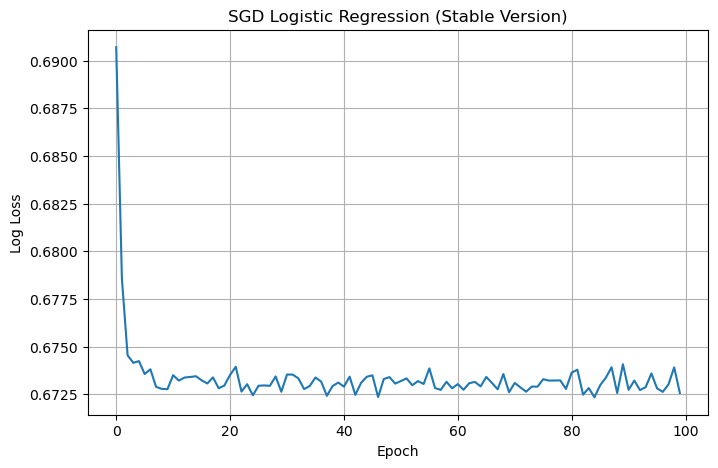

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler

# =========================
# Data
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_full = np.array(y)

classes = np.unique(y_full)

# =========================
# FIXED MODEL
# =========================
clf = SGDClassifier(
    loss="log_loss",
    learning_rate="constant",
    eta0=0.001,
    random_state=42,
    n_jobs=1   # ✅ CRITICAL FIX
)

train_losses = []

batch_size = 32
epochs = 100

# =========================
# Training
# =========================
for epoch in range(epochs):

    idx = np.random.permutation(len(X_scaled))
    X_shuffled = X_scaled[idx]
    y_shuffled = y_full[idx]

    for i in range(0, len(X_scaled), batch_size):
        clf.partial_fit(
            X_shuffled[i:i+batch_size],
            y_shuffled[i:i+batch_size],
            classes=classes
        )

    # compute loss
    y_prob = clf.predict_proba(X_scaled)
    y_prob = np.clip(y_prob, 1e-10, 1 - 1e-10)

    loss = log_loss(y_full, y_prob)
    train_losses.append(loss)

    print(f"Epoch {epoch+1}/{epochs} | Loss = {loss:.4f}")

# =========================
# Plot
# =========================
plt.figure(figsize=(8,5))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("SGD Logistic Regression (Stable Version)")
plt.grid(True)
plt.show()

## Mini-batch SGD Logistic Regression Convergence

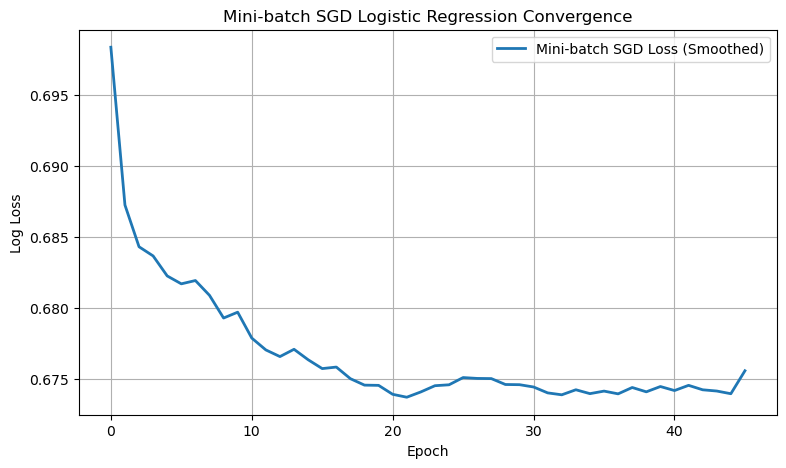

Final loss: 0.6807410924134035


In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler

# =========================
# Standardization
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_full = y

classes = np.unique(y_full)

# =========================
# Model
# =========================
# ❗ REMOVE n_jobs and avoid parallel issues
clf = SGDClassifier(
    loss="log_loss",
    learning_rate="optimal",
    random_state=42
)

# =========================
# Training settings
# =========================
epochs = 50
batch_size = 32

losses = []

# =========================
# Mini-batch SGD training loop
# =========================
for epoch in range(epochs):

    # shuffle data
    idx = np.random.permutation(len(X_scaled))
    X_shuffled = X_scaled[idx]
    y_shuffled = y_full[idx]

    # mini-batch updates
    for i in range(0, len(X_scaled), batch_size):
        X_batch = X_shuffled[i:i + batch_size]
        y_batch = y_shuffled[i:i + batch_size]

        clf.partial_fit(X_batch, y_batch, classes=classes)

    # =========================
    # Compute full loss
    # =========================
    y_prob = clf.predict_proba(X_scaled)
    y_prob = np.clip(y_prob, 1e-10, 1 - 1e-10)

    loss = log_loss(y_full, y_prob)
    losses.append(loss)

# =========================
# Smooth curve
# =========================
def smooth_curve(data, window=5):
    return np.convolve(data, np.ones(window) / window, mode='valid')

loss_smooth = smooth_curve(losses)

# =========================
# Plot
# =========================
plt.figure(figsize=(9, 5))

plt.plot(loss_smooth, label="Mini-batch SGD Loss (Smoothed)", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Mini-batch SGD Logistic Regression Convergence")
plt.legend()
plt.grid(True)

plt.show()

print("Final loss:", losses[-1])